# Demo: Reproducible Portfolio Optimization with Yahoo Finance Data

This notebook demonstrates how to use the `portfolio_project` package to construct and evaluate different portfolio optimization strategies using real stock price data from Yahoo Finance.

We compare three portfolio construction methods:

1. Equal-weight portfolio
2. Minimum-variance portfolio
3. Maximum-Sharpe portfolio

The project uses daily price data, computes asset returns, estimates expected returns and covariance matrices from the training period, and evaluates out-of-sample performance on the testing period.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from portfolio_project.data import download_price_data
from portfolio_project.features import compute_returns, split_train_test
from portfolio_project.optimization import (
    equal_weight_portfolio,
    minimum_variance_portfolio,
    maximum_sharpe_portfolio,
)
from portfolio_project.backtest import (
    compute_portfolio_returns,
    compute_cumulative_returns,
)
from portfolio_project.metrics import performance_summary

## Project Settings

We use a diversified set of large-cap U.S. stocks from different sectors. The training period is used to estimate expected returns and the covariance matrix, while the testing period is used for out-of-sample evaluation.

In [2]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "JPM", "XOM", "JNJ", "PG"]

start_date = "2018-01-01"
end_date = "2024-12-31"
split_date = "2022-01-01"

## Download Price Data

We download daily stock price data from Yahoo Finance. The package uses adjusted prices through `auto_adjust=True`, so the price series accounts for corporate actions such as dividends and stock splits.

In [3]:
prices = download_price_data(tickers, start_date, end_date)

prices.head()
prices.tail()

[*********************100%***********************]  8 of 8 completed


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,MSFT,PG,XOM
Date,,,,,,,,
2024-12-23,253.883133,225.059998,193.734344,140.209900,231.216537,431.078827,161.412720,101.857849
2024-12-24,256.797211,229.050003,195.207535,140.769684,235.018600,435.119720,162.209656,101.953667
2024-12-26,257.612701,227.050003,194.699890,140.509079,235.823608,433.911407,163.381042,102.039894
2024-12-27,254.201385,223.750000,191.872925,139.997543,233.912903,426.404083,162.776154,102.030327
2024-12-30,250.829803,221.300003,190.359940,138.347107,232.118561,420.758698,160.433350,101.340416


## Price Visualization

The plot below shows the historical price movements of the selected stocks. Since the stocks have different price levels, the plot is mainly used for a visual overview rather than direct performance comparison.

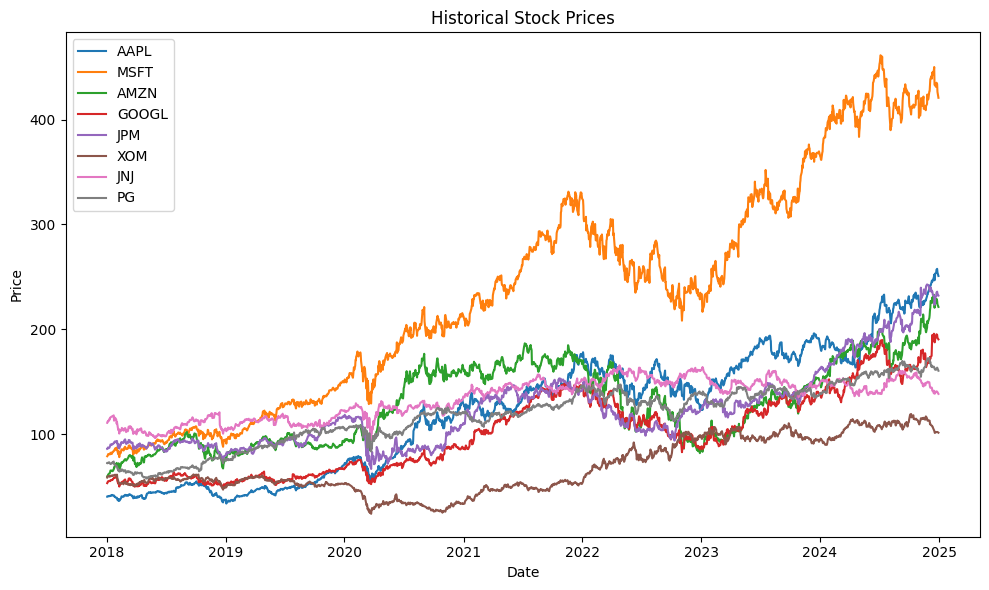

In [4]:
plt.figure(figsize=(10, 6))

for ticker in tickers:
    plt.plot(prices.index, prices[ticker], label=ticker)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

## Compute Daily Returns

We convert prices into daily percentage returns. Portfolio optimization is based on return data rather than raw prices.

In [5]:
returns = compute_returns(prices)

returns.head()
returns.describe()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,MSFT,PG,XOM
count,1759.000000,1759.000000,1759.000000,1759.000000,1759.000000,1759.000000,1759.000000,1759.000000
mean,0.001225,0.000982,0.000913,0.000203,0.000738,0.001118,0.000534,0.000502
std,0.019247,0.021684,0.019397,0.012326,0.018646,0.018201,0.012682,0.019525
min,-0.128647,-0.140494,-0.116341,-0.100379,-0.149649,-0.147390,-0.087373,-0.122248
25%,-0.008046,-0.009881,-0.008490,-0.005487,-0.007775,-0.007451,-0.005502,-0.009744
50%,0.001285,0.001186,0.001327,0.000400,0.000668,0.001286,0.000761,0.000243
75%,0.011512,0.012228,0.010863,0.006071,0.009122,0.010732,0.006895,0.010690
max,0.119808,0.135359,0.102244,0.079977,0.180125,0.142169,0.120090,0.126868


## Train-Test Split

We use data before 2022-01-01 as the training period. The training data is used to estimate expected returns and covariance. Data from 2022 onward is reserved for out-of-sample backtesting.

In [6]:
train_returns, test_returns = split_train_test(returns, split_date)

print("Training period:")
print(train_returns.index.min(), "to", train_returns.index.max())

print("\nTesting period:")
print(test_returns.index.min(), "to", test_returns.index.max())

print("\nTrain shape:", train_returns.shape)
print("Test shape:", test_returns.shape)

Training period:
2018-01-03 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-01-03 00:00:00 to 2024-12-30 00:00:00

Train shape: (1007, 8)
Test shape: (752, 8)


## Estimate Inputs for Optimization

Using the training period, we estimate the mean daily return vector and covariance matrix. These estimates are then used to construct optimized portfolios.

In [7]:
mean_returns = train_returns.mean().values
cov_matrix = train_returns.cov().values

mean_returns

pd.DataFrame(cov_matrix, index=tickers, columns=tickers)

,AAPL,MSFT,AMZN,GOOGL,JPM,XOM,JNJ,PG
AAPL,0.000429,0.000263,0.000255,0.000123,0.000194,0.000295,0.000122,0.000161
MSFT,0.000263,0.000386,0.000241,0.000082,0.000113,0.000263,0.000078,0.000094
AMZN,0.000255,0.000241,0.000340,0.000111,0.000188,0.000275,0.000102,0.000172
GOOGL,0.000123,0.000082,0.000111,0.000186,0.000127,0.000131,0.000114,0.000114
JPM,0.000194,0.000113,0.000188,0.000127,0.000422,0.000194,0.000112,0.000298
XOM,0.000295,0.000263,0.000275,0.000131,0.000194,0.000353,0.000128,0.000154
JNJ,0.000122,0.000078,0.000102,0.000114,0.000112,0.000128,0.000189,0.000093
PG,0.000161,0.000094,0.000172,0.000114,0.000298,0.000154,0.000093,0.000445


## Construct Portfolios

We construct three portfolios:

- Equal Weight: assigns the same weight to every asset.
- Minimum Variance: minimizes portfolio variance subject to long-only weights and weights summing to one.
- Maximum Sharpe: maximizes the Sharpe ratio using estimated returns and covariance.

In [8]:
equal_weights = equal_weight_portfolio(len(tickers))
min_var_weights = minimum_variance_portfolio(cov_matrix)
max_sharpe_weights = maximum_sharpe_portfolio(mean_returns, cov_matrix)

weights_df = pd.DataFrame({
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights,
}, index=tickers)

weights_df

,Equal Weight,Minimum Variance,Maximum Sharpe
AAPL,0.125,0.000000e+00,3.163698e-01
MSFT,0.125,1.735871e-01,0.000000e+00
AMZN,0.125,4.886530e-17,1.108545e-17
GOOGL,0.125,3.552322e-01,0.000000e+00
JPM,0.125,0.000000e+00,0.000000e+00
XOM,0.125,1.278170e-16,4.453801e-01
JNJ,0.125,3.757477e-01,2.382501e-01
PG,0.125,9.543310e-02,6.340745e-17


## Portfolio Weights

The following table and bar plot show how each method allocates capital across assets.

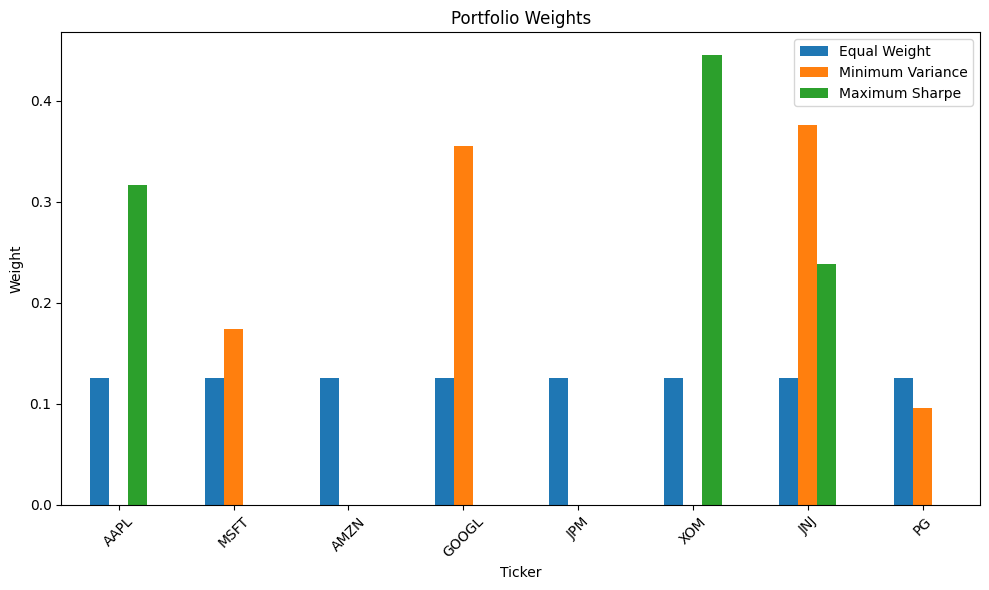

In [9]:
weights_df.plot(kind="bar", figsize=(10, 6))

plt.title("Portfolio Weights")
plt.xlabel("Ticker")
plt.ylabel("Weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Out-of-Sample Backtest

We apply the portfolio weights estimated from the training period to the testing period returns. This gives an out-of-sample comparison of the three strategies.

In [10]:
strategy_returns = {
    "Equal Weight": compute_portfolio_returns(test_returns, equal_weights),
    "Minimum Variance": compute_portfolio_returns(test_returns, min_var_weights),
    "Maximum Sharpe": compute_portfolio_returns(test_returns, max_sharpe_weights),
}

strategy_returns.keys()

dict_keys(['Equal Weight', 'Minimum Variance', 'Maximum Sharpe'])

## Cumulative Returns

The cumulative return plot compares the growth of one dollar invested in each strategy during the out-of-sample testing period.

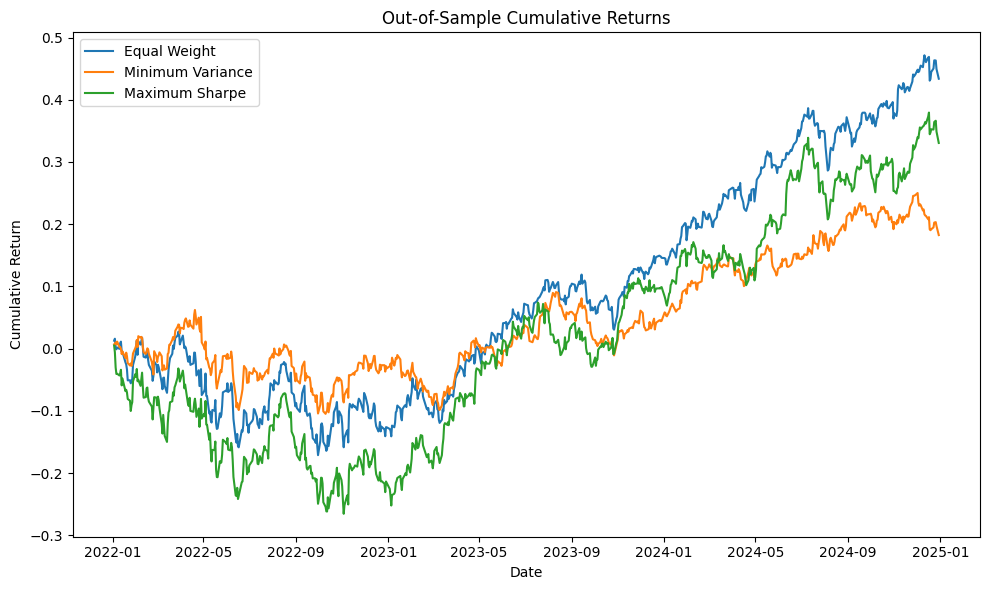

In [11]:
plt.figure(figsize=(10, 6))

for name, returns_series in strategy_returns.items():
    cumulative_returns = compute_cumulative_returns(returns_series)
    plt.plot(cumulative_returns.index, cumulative_returns, label=name)

plt.title("Out-of-Sample Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

## Performance Summary

We evaluate each strategy using annualized return, annualized volatility, Sharpe ratio, and maximum drawdown.

In [12]:
summary = performance_summary(strategy_returns)

summary

,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
Strategy,,,,
Equal Weight,0.128337,0.172750,0.742906,-0.193244
Minimum Variance,0.057781,0.137010,0.421728,-0.157169
Maximum Sharpe,0.100436,0.208608,0.481457,-0.269011


## Interpretation

The results show how different portfolio construction methods lead to different risk-return profiles.

The equal-weight portfolio provides a simple benchmark that does not rely on estimated returns or covariance optimization. The minimum-variance portfolio focuses on reducing risk, so it may have lower volatility and drawdown, but it does not necessarily generate the highest return. The maximum-Sharpe portfolio uses both expected returns and covariance estimates, so it may achieve stronger risk-adjusted performance, but it can also be more sensitive to estimation error.

Overall, this demo shows that portfolio optimization can be implemented in a reproducible Python package and evaluated through out-of-sample backtesting.

## Unit Tests and Reproducibility

The core computational functions are tested using `pytest`. The tests cover return calculation, train-test splitting, portfolio optimization, backtesting, and performance metrics.

To run the tests from the project root directory:

```bash
py -m pytest
```
To check test coverage:
```bash
py -m pytest --cov=portfolio_project
```
In the current implementation, total test coverage is above 80%, satisfying the project requirement for high unit-test coverage.